In [1]:
#!pip install keras

In [2]:
#!pip install tensorflow

In [3]:
#!pip install xgboost

In [4]:
#!pip install lazypredict

# 1 - Import das bibliotecas

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib
import keras
import matplotlib.pyplot as plt

from keras import optimizers
from keras import regularizers
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
from datetime import datetime
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier


I0000 00:00:1781069363.866922  121178 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781069363.905702  121178 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781069364.909804  121178 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# 2 - Leitura inicial do dataset

In [6]:
df = pd.read_csv("data/heart_statlog_cleveland_hungary_final.csv")
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


In [7]:
print("Shape original:", df.shape)
print("\nDistribuição do target:")
print(df['target'].value_counts())
print(f"\nProporção: {df['target'].value_counts(normalize=True).round(3).to_dict()}")

Shape original: (1190, 12)

Distribuição do target:
target
1    629
0    561
Name: count, dtype: int64

Proporção: {1: 0.529, 0: 0.471}


# 4 - Analisando os dados

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [9]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [10]:
df.isnull().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

In [11]:
# Verificar duplicatas
print(f"Total de linhas duplicadas: {df.duplicated().sum()}")
print(f"Percentual: {df.duplicated().sum()/len(df)*100:.1f}%")

Total de linhas duplicadas: 272
Percentual: 22.9%


### 4.1 - Verificando as duplicadas

In [12]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
831,29,1,2,130,204,0,2,202,0,0.0,1,0
1019,29,1,2,130,204,0,2,202,0,0.0,1,0
755,34,0,2,118,210,0,0,192,0,0.7,1,0
1112,34,0,2,118,210,0,0,192,0,0.7,1,0
791,34,1,1,118,182,0,2,174,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1120,74,0,2,120,269,0,2,121,1,0.2,1,0
690,76,0,3,140,197,0,1,116,0,1.1,2,0
1144,76,0,3,140,197,0,1,116,0,1.1,2,0
816,77,1,4,125,304,0,2,162,1,0.0,1,1


São duplicatas exatas em todas as colunas, claramente registros repetidos da coleta, não pacientes diferentes com perfis idênticos. É necessária a remoção

In [13]:
print(f"Shape antes: {df.shape}")

df = df.drop_duplicates()
df = df.reset_index(drop=True)

print(f"Shape depois: {df.shape}")
print(f"Linhas removidas: {1190 - len(df)}")

Shape antes: (1190, 12)
Shape depois: (918, 12)
Linhas removidas: 272


# 5 - Analise Exploratória

,Quantidade:,Percentual (%)
target,,
1,508,55.34
0,410,44.66


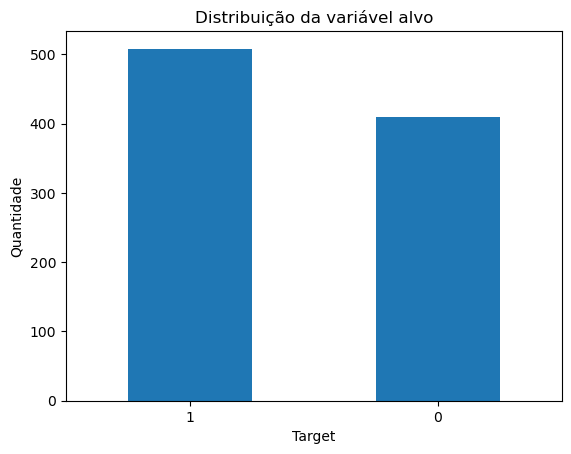

In [14]:
coluna_alvo = "target"

cont_alvos = df[coluna_alvo].value_counts()
porcent_alvo = df[coluna_alvo].value_counts(normalize = True) * 100

display(pd.DataFrame({
    "Quantidade:": cont_alvos,
    "Percentual (%)": porcent_alvo.round(2)
}))

cont_alvos.plot(kind="bar")
plt.title("Distribuição da variável alvo")
plt.xlabel("Target")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

In [15]:
import seaborn as sns

sns.set_theme(style="whitegrid")

colunas_numericas = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]
colunas_categoricas = ["sex", "chest pain type", "fasting blood sugar",
                       "resting ecg", "exercise angina", "ST slope"]

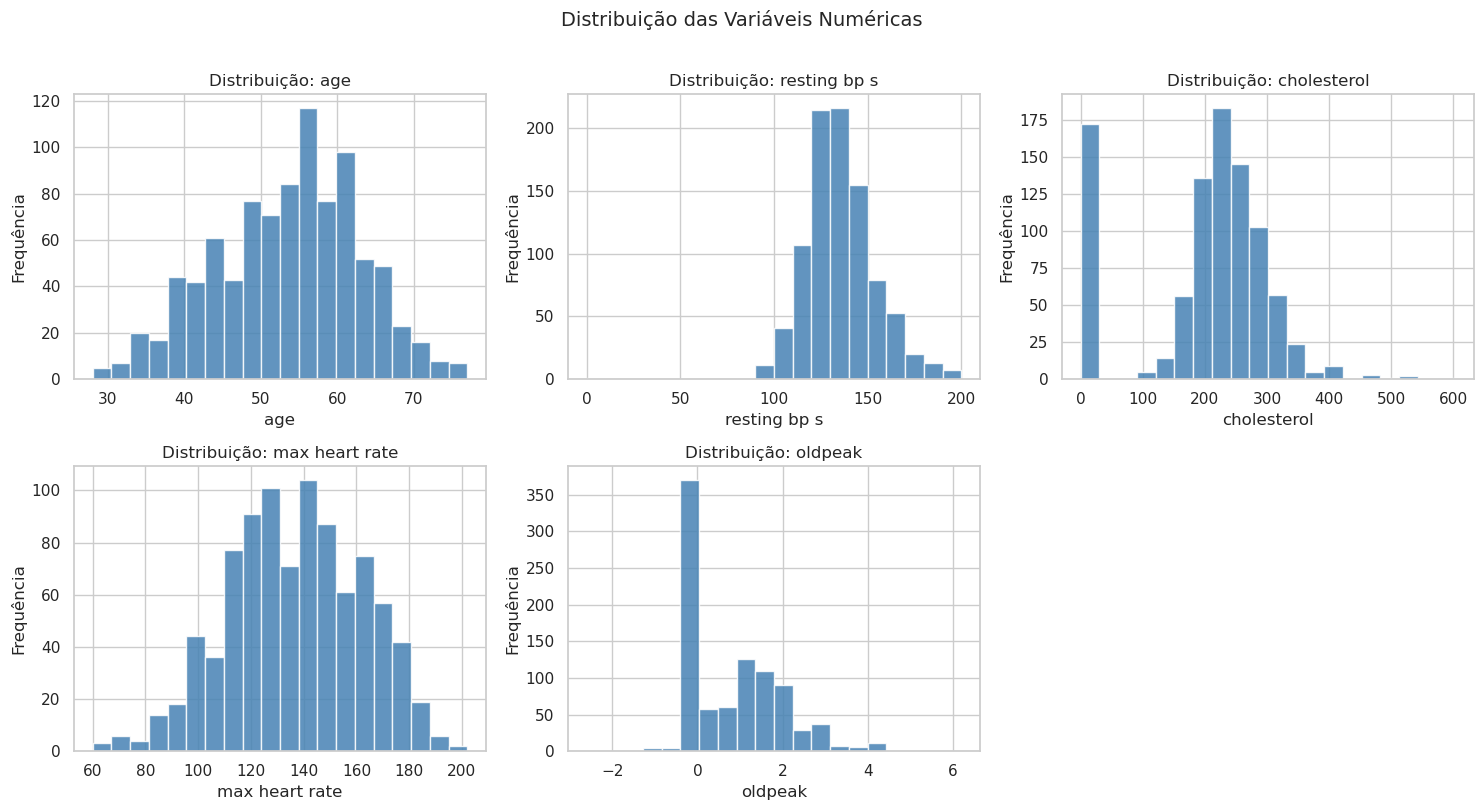

In [16]:
# 1. Distribuição das variáveis numéricas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    axes[i].hist(df[col], bins=20, edgecolor="white", color="steelblue", alpha=0.85)
    axes[i].set_title(f"Distribuição: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequência")

axes[-1].set_visible(False)  # esconde o subplot vazio
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.1 - Boxplots

/tmp/ipykernel_121178/540244245.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_121178/540244245.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_121178/540244245.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_121178/540244245.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

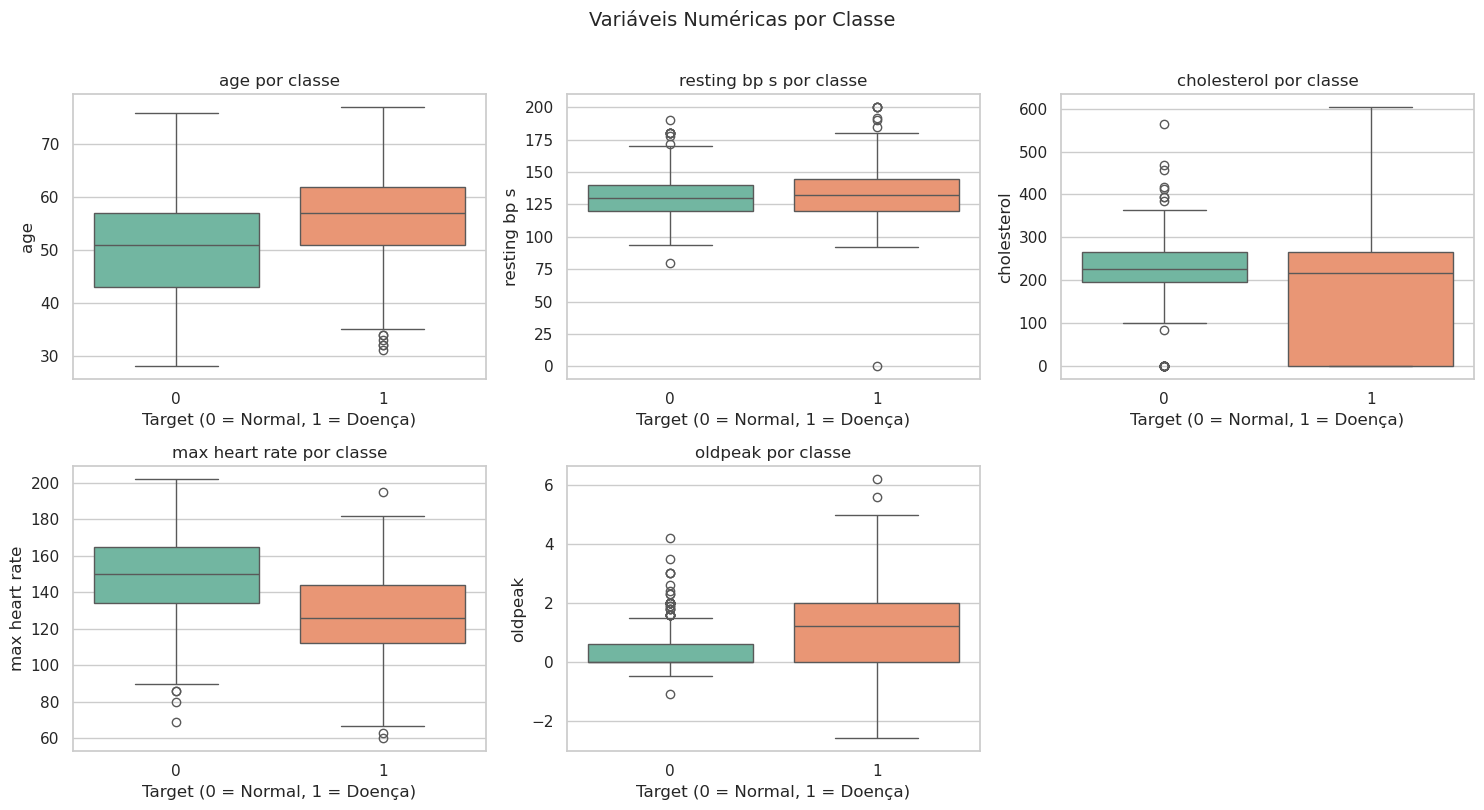

In [17]:
#  2. Boxplots por classe (target) 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(data=df, x="target", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} por classe")
    axes[i].set_xlabel("Target (0 = Normal, 1 = Doença)")

axes[-1].set_visible(False)
plt.suptitle("Variáveis Numéricas por Classe", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.2 - Countplots

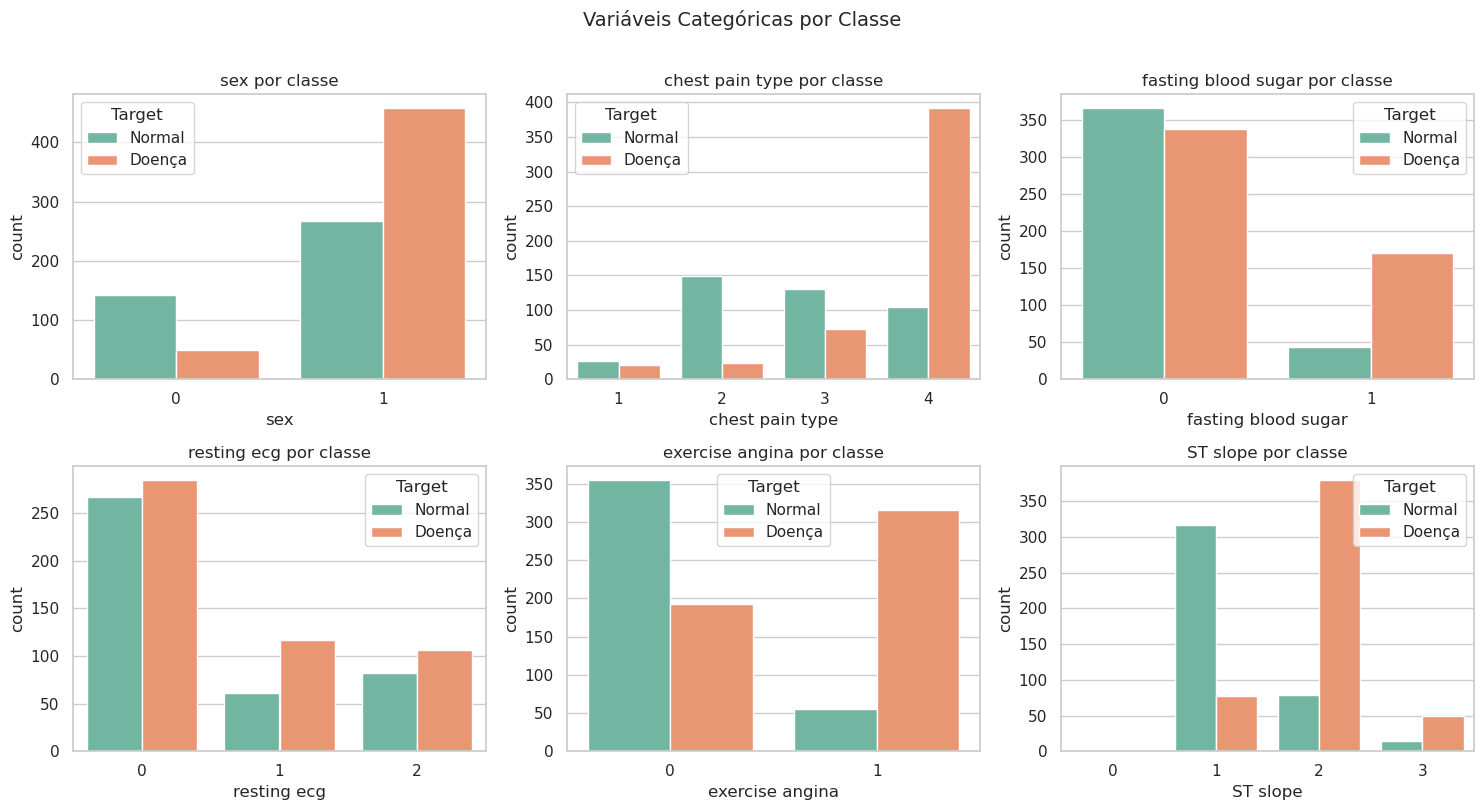

In [18]:
# Countplots das variáveis categóricas por classe
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    sns.countplot(data=df, x=col, hue="target", ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} por classe")
    axes[i].set_xlabel(col)
    axes[i].legend(title="Target", labels=["Normal", "Doença"])

plt.suptitle("Variáveis Categóricas por Classe", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5.3 - Matriz de correlação

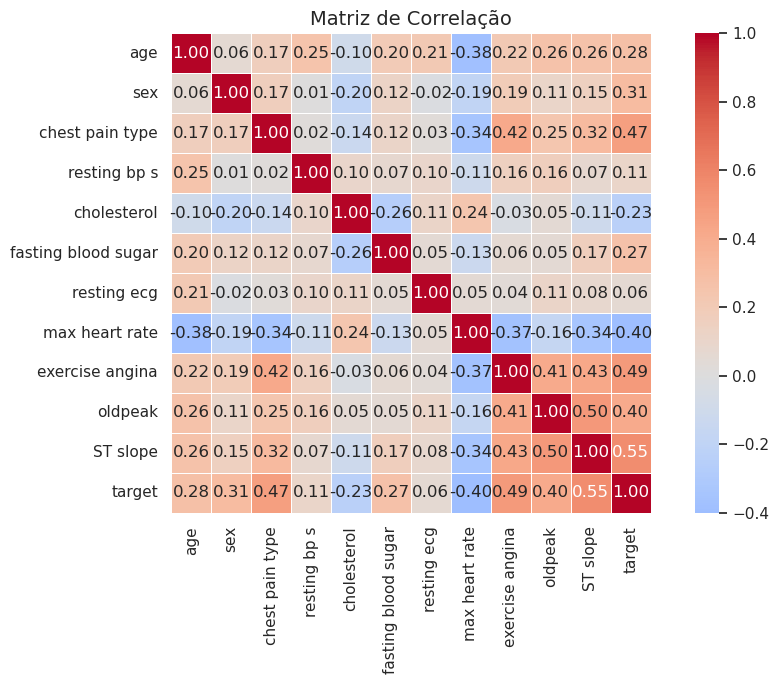

In [19]:
# Matriz de correlação
plt.figure(figsize=(10, 7))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Matriz de Correlação", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
print(corr)

                          age       sex  chest pain type  resting bp s  \
age                  1.000000  0.055750         0.165896      0.254399   
sex                  0.055750  1.000000         0.168254      0.005133   
chest pain type      0.165896  0.168254         1.000000      0.022168   
resting bp s         0.254399  0.005133         0.022168      1.000000   
cholesterol         -0.095282 -0.200092        -0.136139      0.100893   
fasting blood sugar  0.198039  0.120076         0.116703      0.070193   
resting ecg          0.213152 -0.018343         0.031383      0.097661   
max heart rate      -0.382045 -0.189186        -0.343654     -0.112135   
exercise angina      0.215793  0.190664         0.416625      0.155101   
oldpeak              0.258612  0.105734         0.245027      0.164803   
ST slope             0.261760  0.148282         0.317256      0.071477   
target               0.282039  0.305445         0.471354      0.107589   

                     cholesterol  fas

### 5.4 - Analisando outliers

In [21]:
# ── 5. Outliers via IQR (resumo tabular) ─────────────────────────
def contar_outliers_iqr(df, colunas):
    resultado = []
    for col in colunas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
        resultado.append({
            "Variável": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "N° Outliers": len(outliers),
            "% do total": f"{len(outliers)/len(df)*100:.1f}%"
        })
    return pd.DataFrame(resultado).set_index("Variável")

display(contar_outliers_iqr(df, colunas_numericas))

,Q1,Q3,IQR,N° Outliers,% do total
Variável,,,,,
age,47.00,60.0,13.00,0,0.0%
resting bp s,120.00,140.0,20.00,28,3.1%
cholesterol,173.25,267.0,93.75,183,19.9%
max heart rate,120.00,156.0,36.00,2,0.2%
oldpeak,0.00,1.5,1.50,16,1.7%


### 5.4.1 - Analisando a feature cholesterol

In [22]:
print((df["cholesterol"] == 0).sum())
df[df["cholesterol"] == 0]["cholesterol"].describe()

172


count    172.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: cholesterol, dtype: float64

In [23]:
df[df["cholesterol"] == 0]

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
293,65,1,4,115,0,0,0,93,1,0.0,2,1
294,32,1,1,95,0,1,0,127,0,0.7,1,1
295,61,1,4,105,0,1,0,110,1,1.5,1,1
296,50,1,4,145,0,1,0,139,1,0.7,2,1
297,57,1,4,110,0,1,1,131,1,1.4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,1,4,122,0,0,0,120,0,0.5,1,1
515,63,1,3,130,0,1,1,160,0,3.0,2,0
518,48,1,3,102,0,1,1,110,1,1.0,3,1
535,56,1,4,130,0,0,2,122,1,1.0,2,1


In [24]:
df[df["cholesterol"] == 0]["target"].value_counts()

target
1    152
0     20
Name: count, dtype: int64

### 5.4.2 - Verificando outros valores nulos

In [25]:
colunas_numericas = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]

for col in colunas_numericas:
    zeros = (df[col] == 0).sum()
    if zeros > 0:
        print(f"{col}: {zeros} zeros ({zeros/len(df)*100:.1f}%)")

resting bp s: 1 zeros (0.1%)
cholesterol: 172 zeros (18.7%)
oldpeak: 368 zeros (40.1%)


### 5.4.3 - Imputando pela mediana os valores ausentes

A feature oldpeak não foi necessária, pois os zeros são dados reais

In [26]:
# 1. resting bp s — 1 dado ausente
mediana_bp = df[df["resting bp s"] != 0]["resting bp s"].median()
df["resting bp s"] = df["resting bp s"].replace(0, mediana_bp)

# 2. cholesterol — 172 dados ausentes
mediana_col = df[df["cholesterol"] != 0]["cholesterol"].median()
df["cholesterol"] = df["cholesterol"].replace(0, mediana_col)

# 3. oldpeak — zeros são valores reais

# Verificação final
print(df[["resting bp s", "cholesterol", "oldpeak"]].describe())

       resting bp s  cholesterol     oldpeak
count    918.000000   918.000000  918.000000
mean     132.538126   243.204793    0.887364
std       17.990127    53.401297    1.066570
min       80.000000    85.000000   -2.600000
25%      120.000000   214.000000    0.000000
50%      130.000000   237.000000    0.600000
75%      140.000000   267.000000    1.500000
max      200.000000   603.000000    6.200000


### 5.4.4 - Matriz de correlação com os valores imputados

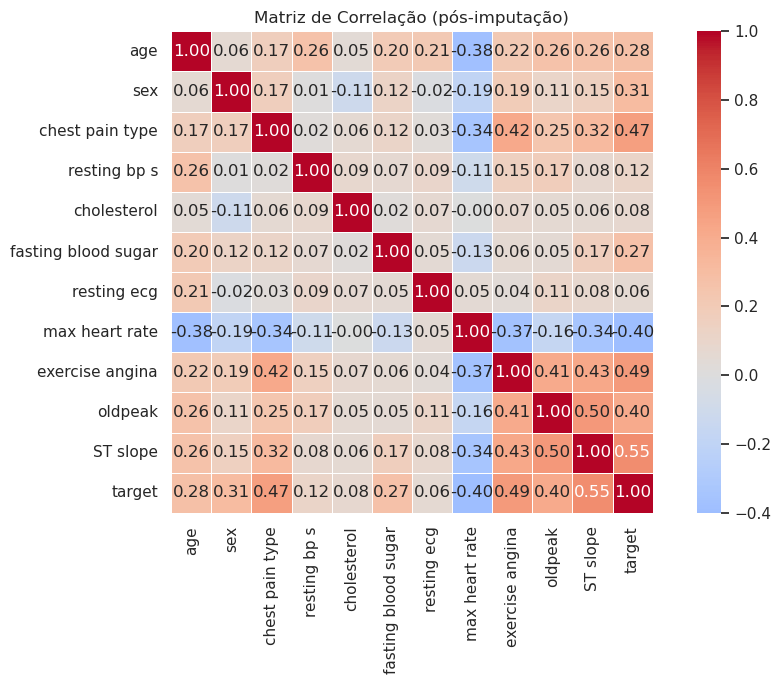

In [27]:
# Após a imputação, gere a matriz novamente
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Matriz de Correlação (pós-imputação)")
plt.tight_layout()
plt.show()

# 6 - Separação das features e target

In [28]:
X = df.drop(columns=["target"])
y = df["target"]

# 1 - Separação dos dados em Treino-Teste-Validação

In [29]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste:  {X_test.shape[0]} amostras")
print(f"Tamanho do conjunto de validação:  {X_val.shape[0]} amostras")
print(f"\nDistribuição no treino:\n{y_train.value_counts()}")
print(f"\nDistribuição no teste:\n{y_test.value_counts()}")
print(f"\nDistribuição na validação:\n{y_val.value_counts()}")


Tamanho do conjunto de treino: 642 amostras
Tamanho do conjunto de teste:  138 amostras
Tamanho do conjunto de validação:  138 amostras

Distribuição no treino:
target
1    355
0    287
Name: count, dtype: int64

Distribuição no teste:
target
1    76
0    62
Name: count, dtype: int64

Distribuição na validação:
target
1    77
0    61
Name: count, dtype: int64


# 1.1 - Visualização da distribuição

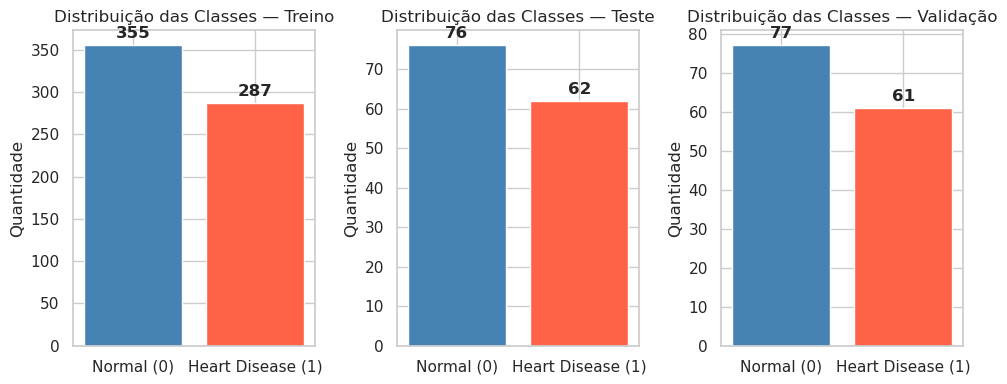

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
 
for ax, (data, title) in zip(axes, [
    (y_train, 'Treino'),
    (y_test,  'Teste'),
    (y_val, 'Validação')
]):
    counts = data.value_counts()
    bars = ax.bar(
        ['Normal (0)', 'Heart Disease (1)'],
        counts.values,
        color=['steelblue', 'tomato']
    )
    ax.bar_label(bars, padding=3, fontweight='bold')
    ax.set_title(f'Distribuição das Classes — {title}')
    ax.set_ylabel('Quantidade')
 
plt.tight_layout()
plt.show()

# 2 - Padronização

In [31]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train.copy())
X_test_std = scaler.transform(X_test.copy())
X_val_std = scaler.transform(X_val.copy())

# Verificação
print("Verificação pós-padronização (treino):")
print(pd.DataFrame(X_train_std, columns=X.columns)
      .describe().T[["mean", "std"]].round(4))

Verificação pós-padronização (treino):
                     mean     std
age                  -0.0  1.0008
sex                  -0.0  1.0008
chest pain type      -0.0  1.0008
resting bp s         -0.0  1.0008
cholesterol          -0.0  1.0008
fasting blood sugar   0.0  1.0008
resting ecg           0.0  1.0008
max heart rate        0.0  1.0008
exercise angina       0.0  1.0008
oldpeak               0.0  1.0008
ST slope              0.0  1.0008


# Treinamento da Rede Neural

# 3 - Modelo

In [32]:
model = Sequential()

model.add(Input(shape=(11,)))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

print(model.summary())

E0000 00:00:1781069368.386719  121178 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781069368.387007  121242 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1781069368.403801  121178 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

None


# 4 - Treinamento

In [33]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_std, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_val_std, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - AUC: 0.4313 - accuracy: 0.4595 - loss: 0.8631 - val_AUC: 0.4260 - val_accuracy: 0.4855 - val_loss: 0.7971
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.5182 - accuracy: 0.5187 - loss: 0.7829 - val_AUC: 0.5753 - val_accuracy: 0.5580 - val_loss: 0.6993
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.5996 - accuracy: 0.5888 - loss: 0.7062 - val_AUC: 0.6975 - val_accuracy: 0.5942 - val_loss: 0.6300
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.6963 - accuracy: 0.6402 - loss: 0.6276 - val_AUC: 0.7783 - val_accuracy: 0.6812 - val_loss: 0.5726
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.7329 - accuracy: 0.6682 - loss: 0.6036 - val_AUC: 0.8353 - val_accuracy: 0.7681 - val_loss: 0.5317
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.7936 - accuracy: 0.7259 - loss: 0.5481 - val_AUC: 0.8685 - val_accuracy: 0.8188 - val_loss: 0.4984
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms

# 5 - Curvas de aprendizado

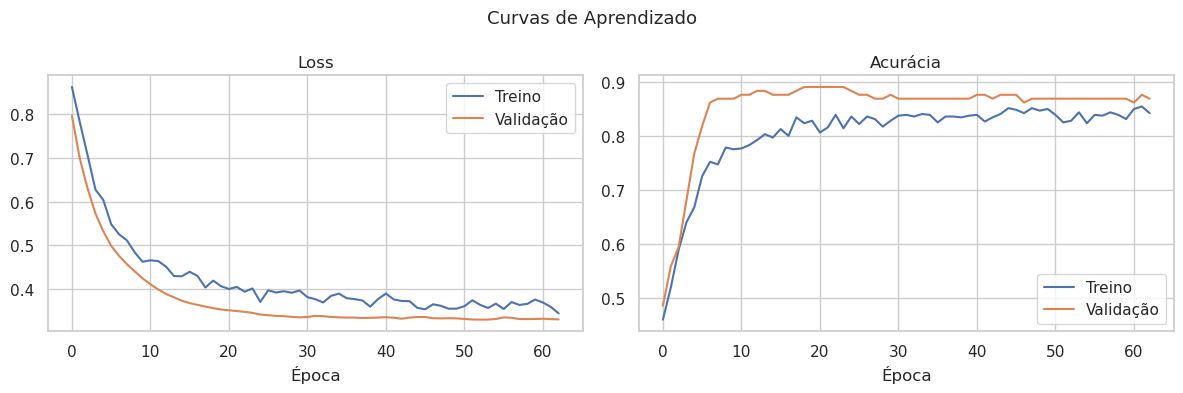

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Treino")
axes[0].plot(history.history["val_loss"], label="Validação")
axes[0].set_title("Loss")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history.history["accuracy"],     label="Treino")
axes[1].plot(history.history["val_accuracy"], label="Validação")
axes[1].set_title("Acurácia")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.suptitle("Curvas de Aprendizado", fontsize=13)
plt.tight_layout()
plt.show()

# 6 - Avaliação no conjunto de teste

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Classification Report
               precision    recall  f1-score   support

       Normal       0.81      0.87      0.84        62
Heart Disease       0.89      0.83      0.86        76

     accuracy                           0.85       138
    macro avg       0.85      0.85      0.85       138
 weighted avg       0.85      0.85      0.85       138

AUC-ROC: 0.9198


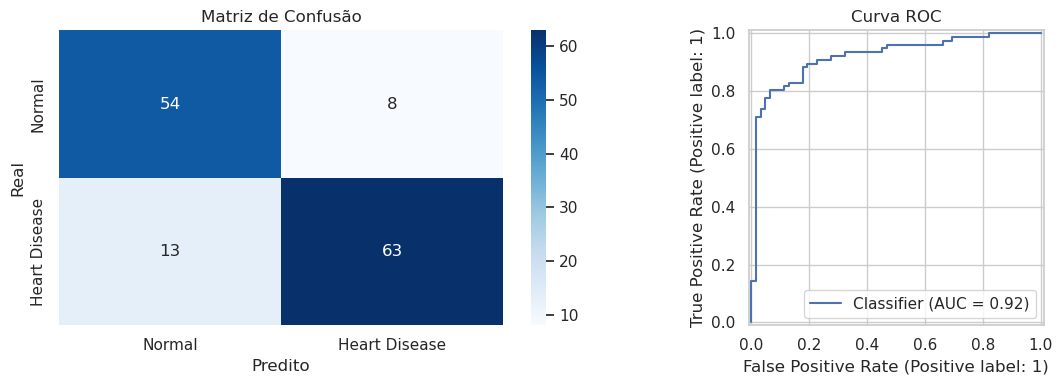

In [35]:
y_pred_prob = model.predict(X_test_std).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print("=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=["Normal", "Heart Disease"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob):.4f}")

# Matriz de confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Heart Disease"],
            yticklabels=["Normal", "Heart Disease"])
axes[0].set_title("Matriz de Confusão")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predito")

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1])
axes[1].set_title("Curva ROC")

plt.tight_layout()
plt.show()

In [36]:
print(f"{'Threshold':<12} {'Precision HD':<15} {'Recall HD':<12} {'F1 HD':<10} {'Acurácia'}")
print("-" * 60)

for threshold in [0.50, 0.45, 0.40, 0.35, 0.30]:
    y_pred_t = (y_pred_prob >= threshold).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True)
    hd = report["1"]
    acc = report["accuracy"]
    print(f"{threshold:<12.2f} {hd['precision']:<15.3f} {hd['recall']:<12.3f} {hd['f1-score']:<10.3f} {acc:.3f}")

Threshold    Precision HD    Recall HD    F1 HD      Acurácia
------------------------------------------------------------
0.50         0.887           0.829        0.857      0.848
0.45         0.851           0.829        0.840      0.826
0.40         0.857           0.868        0.863      0.848
0.35         0.848           0.882        0.865      0.848
0.30         0.848           0.882        0.865      0.848


Resultados com threshold = 0.4
               precision    recall  f1-score   support

       Normal       0.84      0.82      0.83        62
Heart Disease       0.86      0.87      0.86        76

     accuracy                           0.85       138
    macro avg       0.85      0.85      0.85       138
 weighted avg       0.85      0.85      0.85       138

AUC-ROC: 0.9198


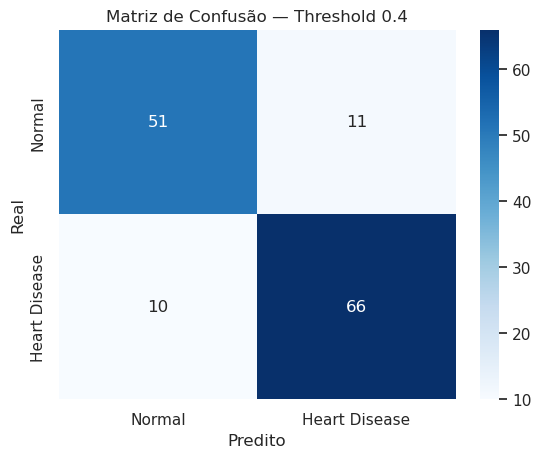

In [37]:
threshold_final = 0.40
y_pred_final = (y_pred_prob >= threshold_final).astype(int)

print("=" * 50)
print(f"Resultados com threshold = {threshold_final}")
print("=" * 50)
print(classification_report(y_test, y_pred_final,
      target_names=["Normal", "Heart Disease"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob):.4f}")

# Matriz de confusão atualizada
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Heart Disease"],
            yticklabels=["Normal", "Heart Disease"])
plt.title(f"Matriz de Confusão — Threshold {threshold_final}")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.show()

# REGRESSÃO LOGÍSTICA

--- TREINANDO REGRESSÃO LOGÍSTICA ---
               precision    recall  f1-score   support

       Normal       0.82      0.81      0.81        62
Heart Disease       0.84      0.86      0.85        76

     accuracy                           0.83       138
    macro avg       0.83      0.83      0.83       138
 weighted avg       0.83      0.83      0.83       138

AUC-ROC: 0.8994


/home/gustavo/anaconda3/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


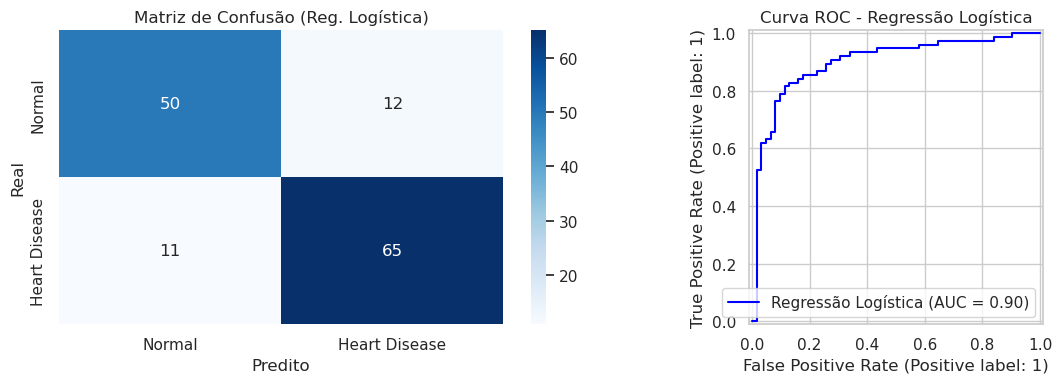

In [38]:
print('--- TREINANDO REGRESSÃO LOGÍSTICA ---')
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_std, y_train)

y_pred_prob_log = log_reg.predict_proba(X_test_std)[:, 1]
y_pred_log = (y_pred_prob_log >= 0.40).astype(int)

print(classification_report(y_test, y_pred_log, target_names=['Normal', 'Heart Disease']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_pred_prob_log):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Heart Disease'], yticklabels=['Normal', 'Heart Disease'])
axes[0].set_title('Matriz de Confusão (Reg. Logística)')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

RocCurveDisplay.from_predictions(y_test, y_pred_prob_log, ax=axes[1], name='Regressão Logística', color='blue')
axes[1].set_title('Curva ROC - Regressão Logística')
plt.tight_layout()
plt.show()

# K-Nearest Neighbors (KNN)

--- TREINANDO K-NEAREST NEIGHBORS (KNN) ---
               precision    recall  f1-score   support

       Normal       0.84      0.79      0.82        62
Heart Disease       0.84      0.88      0.86        76

     accuracy                           0.84       138
    macro avg       0.84      0.84      0.84       138
 weighted avg       0.84      0.84      0.84       138

AUC-ROC: 0.9157


/home/gustavo/anaconda3/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


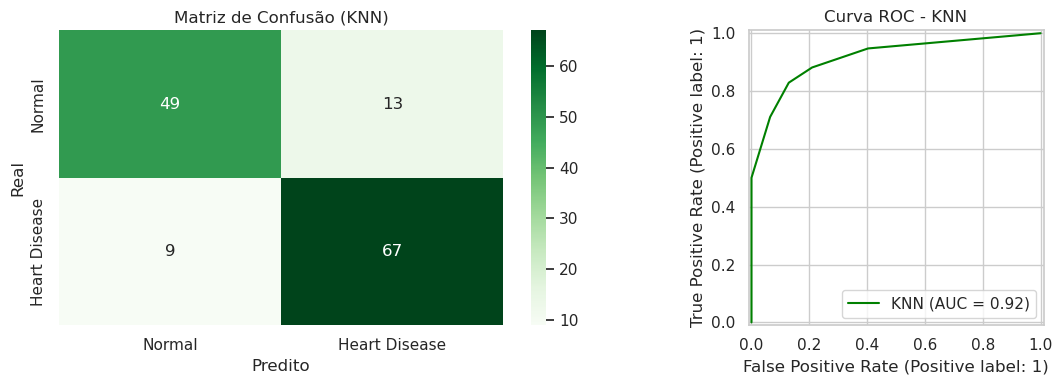

In [39]:
print('--- TREINANDO K-NEAREST NEIGHBORS (KNN) ---')
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_std, y_train)

y_pred_prob_knn = knn.predict_proba(X_test_std)[:, 1]
y_pred_knn = (y_pred_prob_knn >= 0.40).astype(int)

print(classification_report(y_test, y_pred_knn, target_names=['Normal', 'Heart Disease']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_pred_prob_knn):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Normal', 'Heart Disease'], yticklabels=['Normal', 'Heart Disease'])
axes[0].set_title('Matriz de Confusão (KNN)')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

RocCurveDisplay.from_predictions(y_test, y_pred_prob_knn, ax=axes[1], name='KNN', color='green')
axes[1].set_title('Curva ROC - KNN')
plt.tight_layout()
plt.show()

# Treinamento com Random Forest e XGBoost

In [40]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_std, y_train)

y_pred_rf_prob = rf.predict_proba(X_test_std)[:, 1]
y_pred_rf = (y_pred_rf_prob >= 0.40).astype(int)

print(classification_report(y_test, y_pred_rf,
      target_names=["Normal", "Heart Disease"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_rf_prob):.4f}")

               precision    recall  f1-score   support

       Normal       0.87      0.89      0.88        62
Heart Disease       0.91      0.89      0.90        76

     accuracy                           0.89       138
    macro avg       0.89      0.89      0.89       138
 weighted avg       0.89      0.89      0.89       138

AUC-ROC: 0.9456


In [41]:
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb.fit(X_train_std, y_train)

y_pred_xgb_prob = xgb.predict_proba(X_test_std)[:, 1]
y_pred_xgb = (y_pred_xgb_prob >= 0.40).astype(int)

print(classification_report(y_test, y_pred_xgb,
      target_names=["Normal", "Heart Disease"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_xgb_prob):.4f}")

               precision    recall  f1-score   support

       Normal       0.84      0.90      0.87        62
Heart Disease       0.92      0.86      0.88        76

     accuracy                           0.88       138
    macro avg       0.88      0.88      0.88       138
 weighted avg       0.88      0.88      0.88       138

AUC-ROC: 0.9302


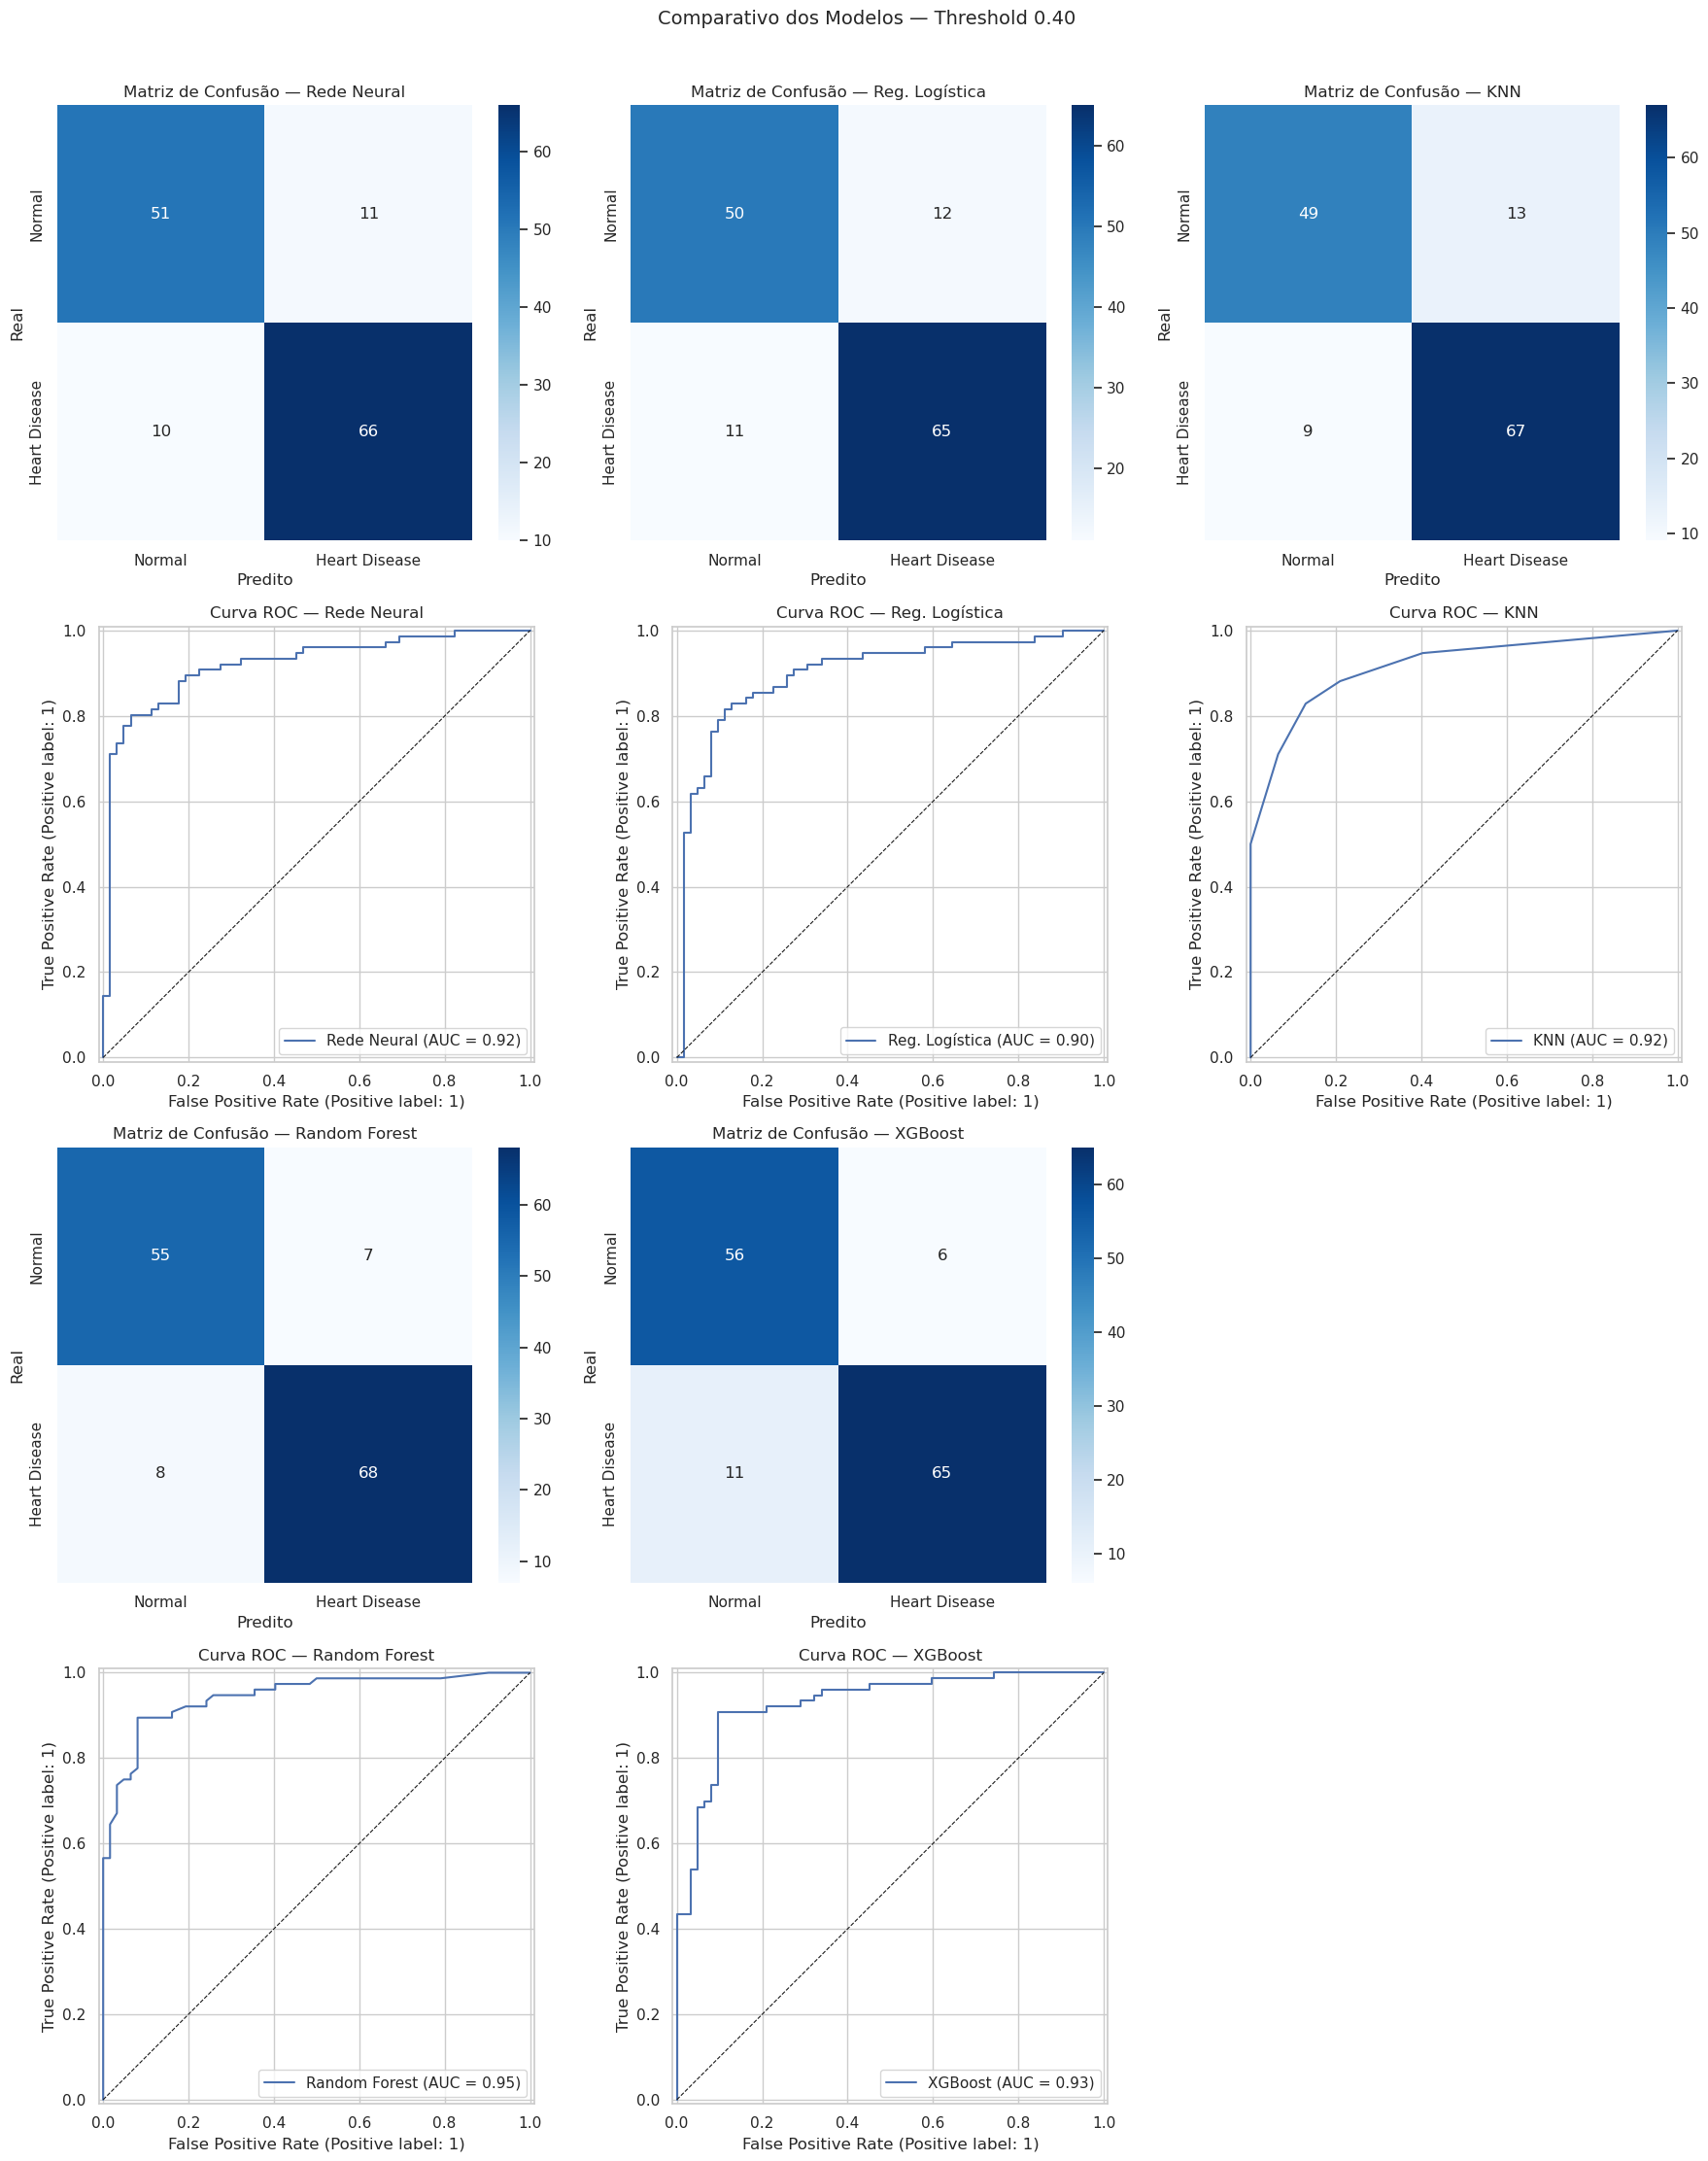

In [42]:
fig, axes = plt.subplots(4, 3, figsize=(18, 22))

modelos = [
    ("Rede Neural",    y_pred_final, y_pred_prob),
    ("Reg. Logística", y_pred_log,   y_pred_prob_log),
    ("KNN",            y_pred_knn,   y_pred_prob_knn),
    ("Random Forest",  y_pred_rf,    y_pred_rf_prob),
    ("XGBoost",        y_pred_xgb,   y_pred_xgb_prob),
]

# Linha 0 — matrizes dos 3 primeiros modelos
for i, (nome, y_pred, _) in enumerate(modelos[:3]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, i],
                xticklabels=["Normal", "Heart Disease"],
                yticklabels=["Normal", "Heart Disease"])
    axes[0, i].set_title(f"Matriz de Confusão — {nome}")
    axes[0, i].set_ylabel("Real")
    axes[0, i].set_xlabel("Predito")

# Linha 1 — ROC dos 3 primeiros modelos
for i, (nome, _, y_prob) in enumerate(modelos[:3]):
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1, i], name=nome)
    axes[1, i].set_title(f"Curva ROC — {nome}")
    axes[1, i].plot([0, 1], [0, 1], "k--", linewidth=0.8)

# Linha 2 — matrizes dos 2 últimos modelos
for i, (nome, y_pred, _) in enumerate(modelos[3:]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2, i],
                xticklabels=["Normal", "Heart Disease"],
                yticklabels=["Normal", "Heart Disease"])
    axes[2, i].set_title(f"Matriz de Confusão — {nome}")
    axes[2, i].set_ylabel("Real")
    axes[2, i].set_xlabel("Predito")
axes[2, 2].set_visible(False)  # terceiro subplot da linha 2 fica vazio

# Linha 3 — ROC dos 2 últimos modelos
for i, (nome, _, y_prob) in enumerate(modelos[3:]):
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[3, i], name=nome)
    axes[3, i].set_title(f"Curva ROC — {nome}")
    axes[3, i].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[3, 2].set_visible(False)  # terceiro subplot da linha 3 fica vazio

plt.suptitle("Comparativo dos Modelos — Threshold 0.40", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [43]:
from lazypredict.Supervised import LazyClassifier

lazy = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None
)

models, predictions = lazy.fit(X_train_std, X_test_std, y_train, y_test)
print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
RandomForestClassifier         0.898551           0.900467  0.945565   
ExtraTreesClassifier           0.876812           0.877759  0.948748   
XGBClassifier                  0.869565           0.872666  0.930178   
AdaBoostClassifier             0.855072           0.856537  0.906303   
GaussianNB                     0.855072           0.856537  0.913625   
KNeighborsClassifier           0.847826           0.849958  0.915747   
QuadraticDiscriminantAnalysis  0.847826           0.845501  0.909805   
BernoulliNB                    0.840580           0.844864  0.925722   
LinearDiscriminantAnalysis     0.840580           0.840407  0.894312   
RidgeClassifier                0.840580           0.840407  0.894312   
RidgeClassifierCV              0.840580           0.840407  0.894737   
CalibratedClassifierCV         0.840580           0.838922  0.89

In [44]:
# Ver os 10 melhores por AUC
print(models.sort_values("ROC AUC", ascending=False).head(10))

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
ExtraTreesClassifier           0.876812           0.877759  0.948748   
RandomForestClassifier         0.898551           0.900467  0.945565   
XGBClassifier                  0.869565           0.872666  0.930178   
NuSVC                          0.833333           0.832343  0.928056   
BernoulliNB                    0.840580           0.844864  0.925722   
BaggingClassifier              0.818841           0.825127  0.922538   
SVC                            0.833333           0.832343  0.919779   
KNeighborsClassifier           0.847826           0.849958  0.915747   
GaussianNB                     0.855072           0.856537  0.913625   
QuadraticDiscriminantAnalysis  0.847826           0.845501  0.909805   

                               F1 Score  Precision    Recall  Time Taken  
Model                                                       